# Lista de Exercício de Aprendizado Profundo - Questão 5

## 0. Requisitos

In [3]:
#pip install numpy pandas matplotlib scikit-learn seaborn

In [4]:
#%pip install tensorflow

## 1. Importação das Bibliotecas

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns 

import numpy as np
import pandas as pd

from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

## 2. Tratamento

### 2.1 Importação do Dataset Fashion Mnist

In [2]:
(X_train, _), (X_test, _) = fashion_mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

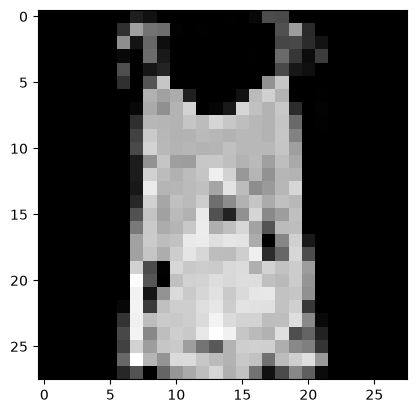

In [4]:
plt.imshow(X_train[67],cmap='gray')
plt.show()

### 2.2 Normalização dos Dados

In [5]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

### 2.3 Redimensionamento das Imagens para Vetores de 784 Pixels

In [6]:
X_train = X_train.reshape((len(X_train), 784))
X_test = X_test.reshape((len(X_test), 784))

## 3. Autoencoder Capaz de Reconstruir Imagens do Fashion-Mnist

### 3.1 Implementação com Camadas Densas

In [26]:
def criar_autoencoder(tamanho_latente):
    
    inputs = Input(shape=(784,))

    encoded = Dense(tamanho_latente,activation="relu",name=f"espaco_latente_{tamanho_latente}")(inputs)

    decoded = Dense(784,activation="sigmoid",name="reconstrucao")(encoded)

    autoencoder = Model(inputs=inputs,outputs=decoded,name=f"autoencoder_{tamanho_latente}")

    autoencoder.compile(optimizer="adam",loss="mse")

    return autoencoder

In [27]:
tamanhos_latentes = [16, 32, 64]

modelos = {}
historicos = {}

for tamanho in tamanhos_latentes:
    
    print(f"Treinando modelo com espaço latente = {tamanho}")

    modelo = criar_autoencoder(tamanho)

    historico = modelo.fit(
        X_train,
        X_train,
        epochs=100,
        batch_size=256,
        shuffle=True,
        validation_data=(X_test, X_test)
    )

    modelos[tamanho] = modelo
    historicos[tamanho] = historico

Treinando modelo com espaço latente = 16
Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0678 - val_loss: 0.0391
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0336 - val_loss: 0.0298
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0273 - val_loss: 0.0254
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0239 - val_loss: 0.0228
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0218 - val_loss: 0.0211
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0205 - val_loss: 0.0199
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0192
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0189 - val_loss: 0.0187
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - val_loss: 0.0184
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0183 - val_loss: 0.0182
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0181 - val_loss: 0.0181


In [28]:
imagens_teste = X_test[:10]

reconstrucoes_16 = modelos[16].predict(imagens_teste)
reconstrucoes_32 = modelos[32].predict(imagens_teste)
reconstrucoes_64 = modelos[64].predict(imagens_teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


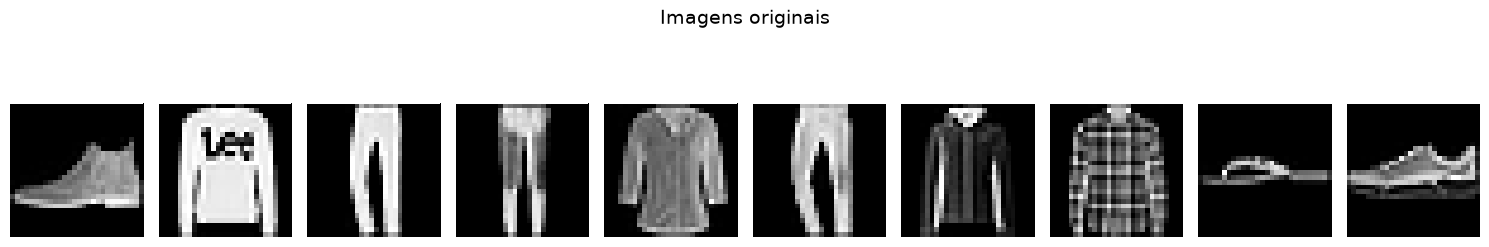

In [30]:
plt.figure(figsize=(15, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(imagens_teste[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Imagens originais", fontsize=14)
plt.tight_layout()
plt.show()

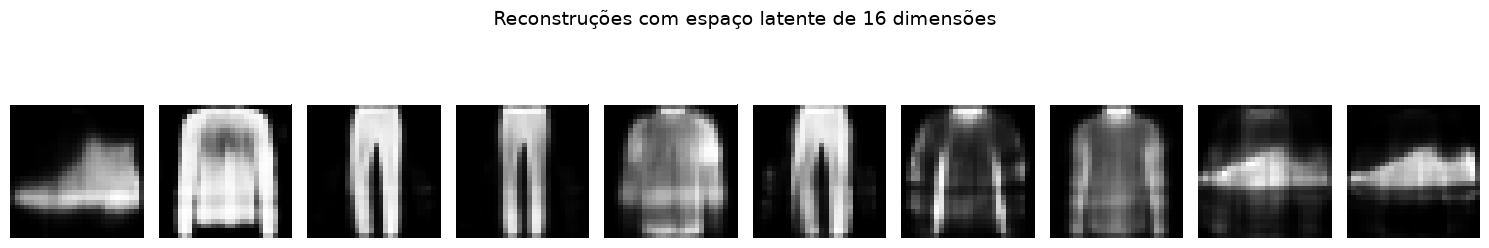

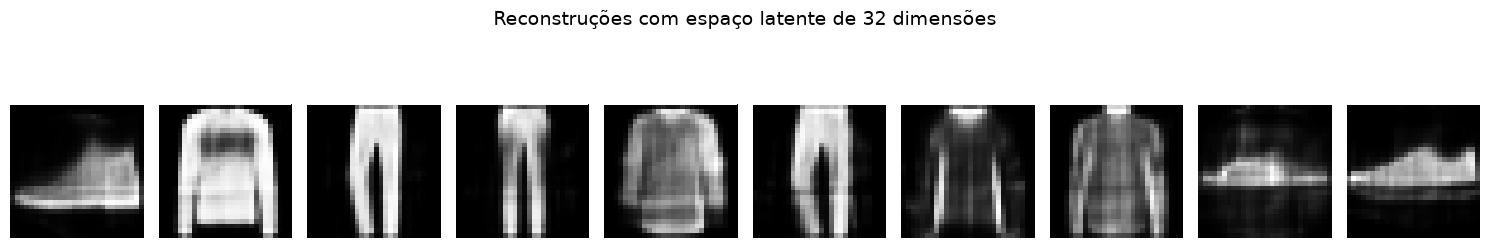

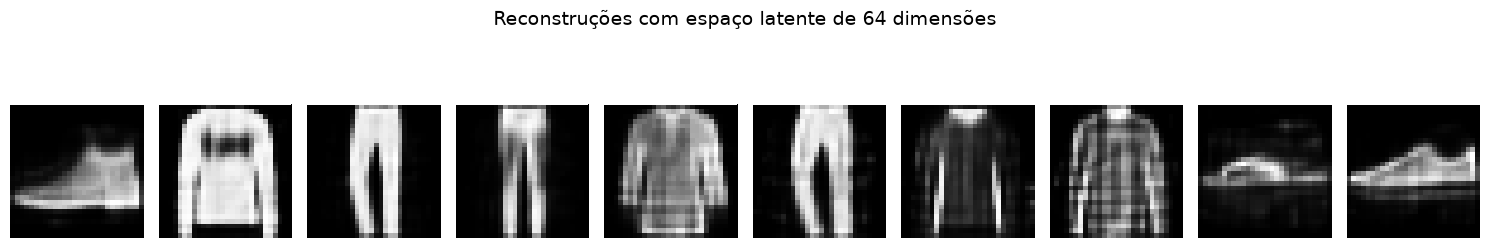

In [29]:
reconstrucoes = {
    16: reconstrucoes_16,
    32: reconstrucoes_32,
    64: reconstrucoes_64
}

for tamanho_latente, imagens_reconstruidas in reconstrucoes.items():

    plt.figure(figsize=(15, 3))

    for i in range(10):
        plt.subplot(1, 10, i + 1)

        imagem = imagens_reconstruidas[i].reshape(28, 28)

        plt.imshow(imagem, cmap="gray")
        plt.axis("off")

    plt.suptitle(
        f"Reconstruções com espaço latente de {tamanho_latente} dimensões",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

### 3.2 Implementação com Camadas Convolucionais

In [31]:
(X_train, _), (X_test, _) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train.shape

(60000, 28, 28, 1)

In [34]:
model = Sequential()

model.add(Input(shape=(28, 28, 1)))

#encod
model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2), padding="same"))

model.add(Conv2D(16,(3, 3),padding="same",activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2),padding="same"))

#decode
model.add(Conv2D(16,(3, 3),padding="same",activation="relu"))
model.add(UpSampling2D(size=(2, 2)))

model.add(Conv2D(32,(3, 3),padding="same",activation="relu"))
model.add(UpSampling2D(size=(2, 2)))

#saida
model.add(Conv2D(1, (3, 3), padding="same", activation="sigmoid"))

In [35]:
model.compile(optimizer="adam", loss="mse")

In [36]:
history = model.fit(
    X_train,
    X_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_test, X_test),
    shuffle=True
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0165 - val_loss: 0.0092
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0079 - val_loss: 0.0070
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.0042 - val_loss: 0.0043


In [ ]:
imagens_teste = X_test[:10]

reconstruidas_conv = model.predict(imagens_teste,verbose=0)

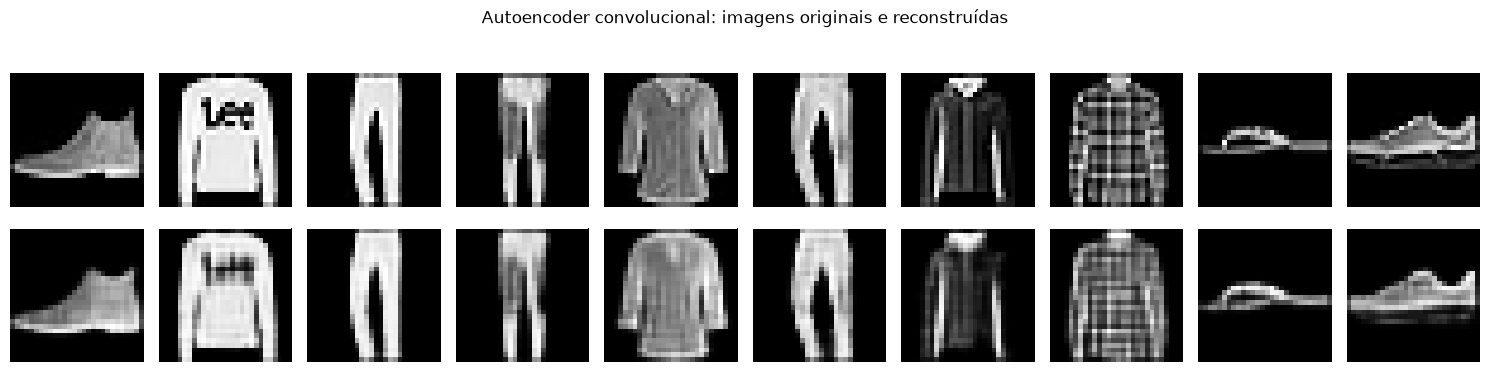

In [39]:
plt.figure(figsize=(15, 4))

for i in range(10):
    
    plt.subplot(2, 10, i + 1)
    plt.imshow(imagens_teste[i].squeeze(), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstruidas_conv[i].squeeze(), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Reconstruída")

plt.suptitle("Autoencoder convolucional: imagens originais e reconstruídas")
plt.tight_layout()
plt.show()

## 4. Utilizando Autoencoders para Remover Ruído das Imagens

In [43]:
(X_train, _), (X_test, _) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train.reshape((len(X_train), 784))
X_test = X_test.reshape((len(X_test), 784))

In [44]:
X_train_noisy = X_train + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0)

In [45]:
inputs = Input(shape=(784,))

encoder = Dense(32, activation='relu')(inputs)

decoder = Dense(784, activation='sigmoid')(encoder)

autoencoder = Model(inputs, decoder)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(X_train_noisy, X_train, epochs=100, batch_size=256, shuffle=True, validation_data= (X_test_noisy, X_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4337 - val_loss: 0.3618
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3440 - val_loss: 0.3374
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3313 - val_loss: 0.3300
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3249 - val_loss: 0.3246
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3201 - val_loss: 0.3210
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3167 - val_loss: 0.3178
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3140 - val_loss: 0.3155
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3118 - val_loss: 0.3135
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3099 - val_loss: 0.3118
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3084 - val_loss: 0.3104
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3071 - val_loss: 0.3094
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━

In [46]:
original_images = X_test[:10]

noisy_images = original_images + 0.5 * np.random.normal(loc=0.0,scale=1.0,size=original_images.shape)

noisy_images = np.clip(noisy_images, 0.0, 1.0)

denoised_images = autoencoder.predict(noisy_images,verbose=0)

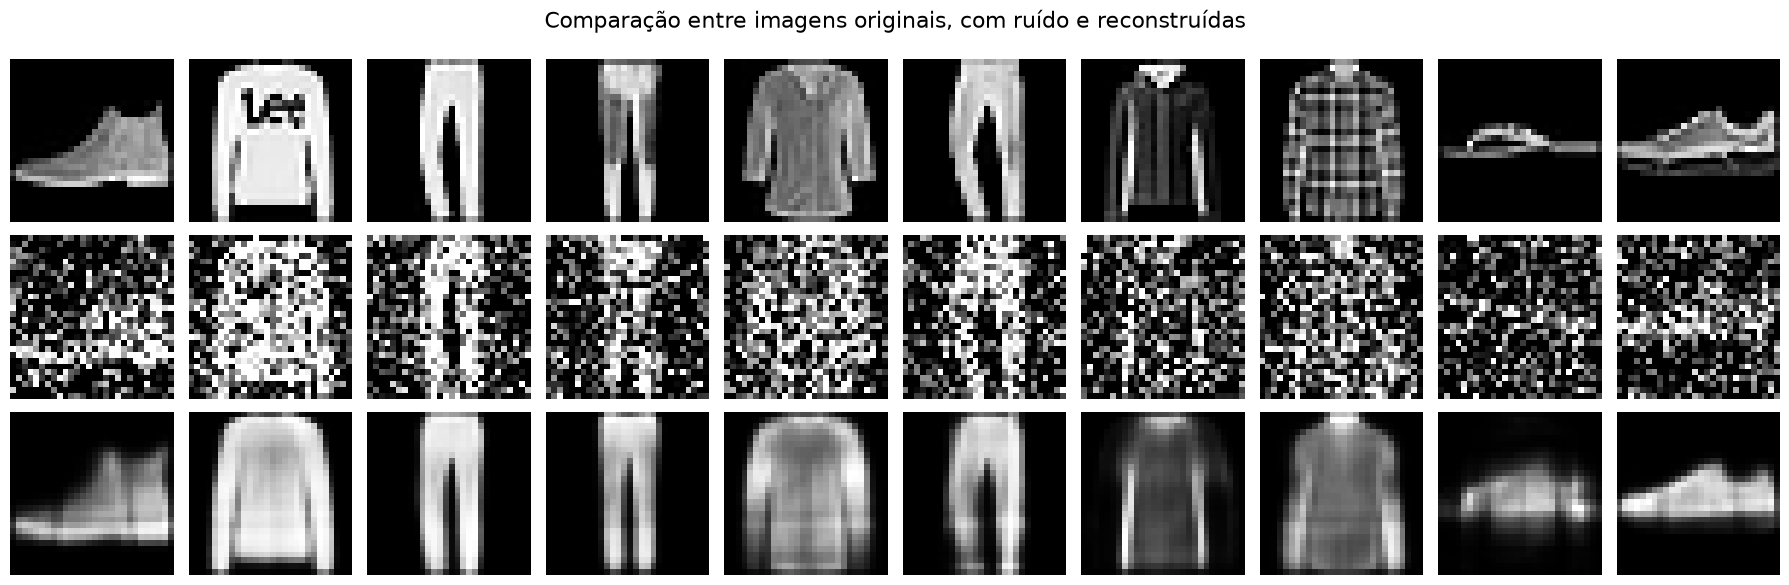

In [47]:
plt.figure(figsize=(18, 6))

for i in range(10):

    plt.subplot(3, 10, i + 1)
    plt.imshow(original_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Original", fontsize=12)

    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Com ruído", fontsize=12)

    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Reconstruída", fontsize=12)

plt.suptitle(
    "Comparação entre imagens originais, com ruído e reconstruídas",
    fontsize=16
)

plt.tight_layout()
plt.show()